# Least Squares Method - Prediction of song release year

The goal of this task is to apply the least squares method to predict the release year of musical tracks based on their audio features (timbre average and covariance).

## Libraries used:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

## Subpoints (a) and (b): Loading and splitting the data
We load the `YearPredictionMSD.txt` dataset and then split it into a training set (first 463,715 examples) and a testing set. We use the `.iloc[]` method, which allows us to slice the data based on their numerical row indices.

In [2]:
# Load data
data = pd.read_csv("YearPredictionMSD.txt",header=None)

# Split into training and testing sets
training_set = data.iloc[:463715]
testing_set = data.iloc[463715:]

# Extract the first column (release year) for the entire dataset
release_year = data[0]

## Subpoint (c): Visualization of the release year distribution
Below we create two plots:
1. **Histogram:** Shows how many songs were released in a given time period.
2. **Sorted line plot:** A step-like function representing the cumulative number of songs over time. To make the plot readable, the original Pandas indices were reset.

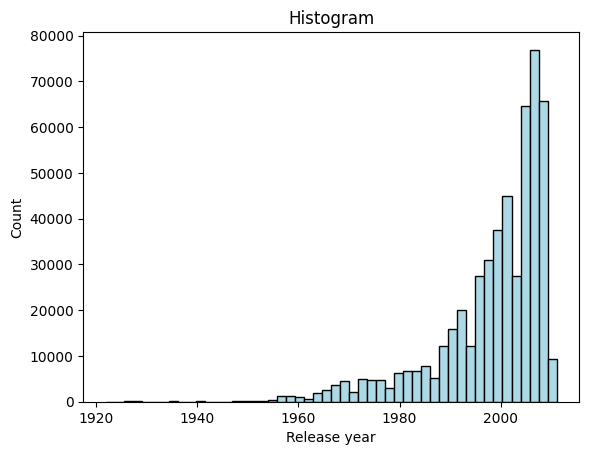

In [3]:
# 1. Histogram

plt.title("Histogram")
plt.hist(release_year, bins=50, color = 'lightblue', edgecolor='black')
plt.xlabel("Release year")
plt.ylabel("Count")
plt.show()

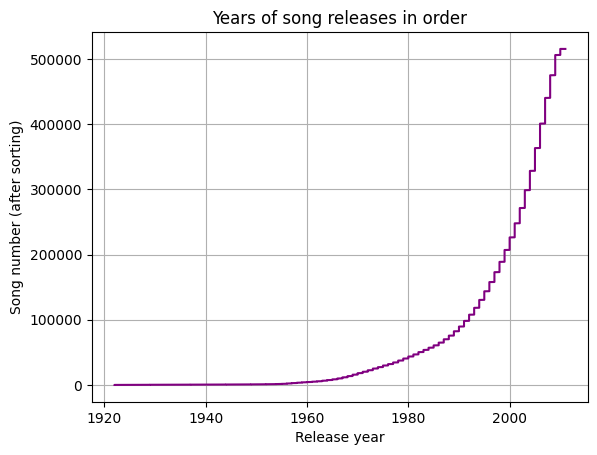

In [4]:
# 2. Sorted plot

release_year_sorted = release_year.sort_values().reset_index(drop=True)

plt.plot(release_year_sorted.values, release_year_sorted.index, color='purple')
plt.grid(True)
plt.title("Years of song releases in order")
plt.ylabel("Song number (after sorting)")
plt.xlabel("Release year")
plt.show()

## Subpoint (d): Data representation and normalization
We separate our data into the target variable ($y$ - release year) and the feature matrix ($X$ - the remaining 90 columns). We use the `.values` property to drop the Pandas indices and work with pure NumPy multi-dimensional arrays.

Next, we apply **Min-Max Scaling** to bring all values into the $[0, 1]$ range, using the broadcasting mechanism in NumPy. The minimum and maximum values are calculated **only** on the training set.

In [5]:
# Training and testing data (unscaled)
y_train = training_set.iloc[:, 0].values
X_train = training_set.iloc[:, 1:].values

y_test = testing_set.iloc[:, 0].values
X_test = testing_set.iloc[:, 1:].values

# Getting Min-Max values
X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)

# Scaling
X_train_scaled = (X_train - X_min) / (X_max - X_min)
X_test_scaled = (X_test - X_min) / (X_max - X_min)

# Obliczamy min i max lat dla treningu
y_min = y_train.min()
y_max = y_train.max()

# Skalujemy lata (y)
y_train_scaled = (y_train - y_min) / (y_max - y_min)
y_test_scaled = (y_test - y_min) / (y_max - y_min)

## Subpoint (e): Least Squares Method (Normal Equation)
We look for the weight vector ($w$) by solving the normal equation:
$$A^T A w = A^T y$$
First, we add a column of ones (`np.ones`) to the feature matrix (for both unscaled and scaled data), which acts as the intercept (bias) term. To solve the system of equations, we use the optimized `np.linalg.solve` function.

We use the equation $A^T A w = A^T y$
where:
- A is a feature matrix (X_train)
- $A^T$ is transposed matrix
- y is the real release year (y_train)
- w is weight vector which we look for

In [6]:
# Unscaled data

ones_train = np.ones((X_train.shape[0], 1))
A_train = np.hstack((ones_train, X_train))

A_T = A_train.T
left_side = A_T @ A_train
right_side = A_T @ y_train

w_unscaled = np.linalg.solve(left_side, right_side)
print("Weight vector shape:", w_unscaled.shape)

Weight vector shape: (91,)


In [7]:
# Scaled data

ones_train_scaled = np.ones((X_train_scaled.shape[0], 1))
A_train_scaled = np.hstack((ones_train_scaled, X_train_scaled))

A_T_scaled = A_train_scaled.T
left_side_scaled = A_T_scaled @ A_train_scaled
right_side_scaled = A_T_scaled @ y_train_scaled

w_scaled = np.linalg.solve(left_side_scaled, right_side_scaled)
print("Weight vector shape (scaled):", w_scaled.shape)

Weight vector shape (scaled): (91,)


## Subpoint (f): Other methods for finding weights
We calculate the weights for the unscaled representation using two other methods:
1. **SVD Decomposition:** Using the numerically safe `scipy.linalg.lstsq` function. (Singular Value Decomposition)
2. **Tikhonov Regularization (Ridge):** Adding an identity matrix ($I$) multiplied by a penalty $\lambda = 0.01$ to the left side of the normal equation. We zero out the first element of the identity matrix to avoid penalizing the bias term.

In [8]:
# 1. SVD method from the SciPy library
w_svd, residuals, rank, s = la.lstsq(A_train, y_train)
print("Weight vector shape (SVD):", w_svd.shape)

# 2. Normal equation with regularization (lambda = 0.01)
lam = 0.01
I = np.eye(A_train.shape[1])
I[0, 0] = 0
left_side_reg = left_side + (lam * I)
w_reg = np.linalg.solve(left_side_reg, right_side)
print("Weight vector shape (regularized):", w_reg.shape)

Weight vector shape (SVD): (91,)
Weight vector shape (regularized): (91,)


## Subpoint (g): Condition Number and Numerical Stability
In this step, we calculate the condition number, $cond(A^T A)$, on the training set for both the unscaled and scaled representations. 

The condition number tells us how sensitive the solution of our linear equations (the weights) is to small numerical errors. 
**Impact on significant digits:** A general rule in numerical mathematics is that if the condition number is $10^k$, we lose approximately $k$ significant digits of precision during the calculation. 
* Unscaled data typically results in a massive condition number (e.g., around $10^9$), meaning we lose about 9 digits of precision. Min-Max scaling significantly lowers this number (e.g., to $10^6$), saving valuable significant digits and making our model much more mathematically stable.

In [9]:
# Calculate the condition number for the unscaled matrix
cond_unscaled = np.linalg.cond(left_side)
print(f"Condition number (unscaled): {cond_unscaled:.4e}")

# Calculate the condition number for the scaled matrix
cond_scaled = np.linalg.cond(left_side_scaled)
print(f"Condition number (scaled): {cond_scaled:.4e}")

Condition number (unscaled): 3.8737e+09
Condition number (scaled): 2.1465e+06


## Subpoint (h): Making Predictions and Calculating Error
Now we check how well the obtained weights predict the release year of a song. 

First, we multiply the test set representation by the calculated weight vector for the unscaled representation. Next, we repeat this multiplication for the scaled representation. Because the scaled predictions are in the $[0, 1]$ range, we must subject them to the inverse of the min-max normalization:
$$t_{unscaled}=\tilde{y}*(y_{max}-y_{min})+y_{min}$$ 

Finally, we use the Mean Absolute Error (MAE) as our error metric to see, on average, how many years our model's predictions deviate from the true release years.

In [13]:
# 1. Prepare test matrices (adding a column of ones, to create bias)
ones_test = np.ones((X_test.shape[0], 1))
A_test = np.hstack((ones_test, X_test))

ones_test_scaled = np.ones((X_test_scaled.shape[0], 1))
A_test_scaled = np.hstack((ones_test_scaled, X_test_scaled))

# 2. Predict using unscaled data
y_pred_unscaled = A_test @ w_unscaled

# 3. Predict using scaled data
y_pred_scaled = A_test_scaled @ w_scaled

# 4. Predict using SVD method
y_pred_svd = A_test @ w_svd

# 5. Predict using Regularizatioon
y_pred_reg = A_test @ w_reg

# Reverse the Min-Max scaling for the scaled predictions
y_pred_scaled_reversed = y_pred_scaled * (y_max - y_min) + y_min

# 4. Calculate Mean Absolute Error (MAE)
mae_unscaled = np.mean(np.abs(y_pred_unscaled - y_test))
mae_scaled = np.mean(np.abs(y_pred_scaled_reversed - y_test))
mae_svd = np.mean(np.abs(y_pred_svd - y_test))
mae_reg = np.mean(np.abs(y_pred_reg - y_test))

print(f"Mean Absolute Error (unscaled): {mae_unscaled:.6f} years")
print(f"Mean Absolute Error (scaled): {mae_scaled:.6f} years")
print(f"Mean Absolute Error (SVD): {mae_svd:.6f} years")
print(f"Mean Absolute Error (Regularization): {mae_reg:.6f} years")

Mean Absolute Error (unscaled): 6.800496 years
Mean Absolute Error (scaled): 6.800496 years
Mean Absolute Error (SVD): 6.800496 years
Mean Absolute Error (Regularization): 6.800496 years


## Subpoint (i): Incremental Learning using the Kalman Filter
In this final step, we implement an incremental approach using a Kalman filter mechanism. 

Instead of loading the entire dataset into memory at once and solving one massive equation (batch learning), we divide the unscaled training matrix $A$ into 5 smaller blocks (four blocks of 100,000 rows and one block of 63,715 rows). 


For each block, the model performs the following iterative steps:
1. **Accumulate Information:** It updates the information matrix ($H_j$), which is the running sum of $A_j^T A_j$.
2. **Calculate Error:** It checks how much the *current* weights deviate on the new batch of data.
3. **Update Weights:** It calculates a correction vector ($d_j$) and adds it to the running weight vector (`w_kalman`).
4. **Evaluate:** It calculates the MAE (mean absolute error) on the *test set* using the newly updated weights.

In [11]:
block_sizes = [100000, 100000, 100000, 100000, 63715]
start_idx = 0

m = A_train.shape[1]
w_kalman = np.zeros(m)
H_j = np.zeros((m, m))

for i, size in enumerate(block_sizes):
    end_idx = start_idx + size
    
    A_j = A_train[start_idx:end_idx, :]
    y_j = y_train[start_idx:end_idx]
    
    H_j = H_j + A_j.T @ A_j
    
    right_side = A_j.T @ (y_j - A_j @ w_kalman)
    d_j = np.linalg.solve(H_j, right_side)
    
    w_kalman = w_kalman + d_j
    
    y_pred_kalman = A_test @ w_kalman
    mae_k = np.mean(np.abs(y_pred_kalman - y_test))
    
    print(f"Step {i+1} (Block {size} rows): MAE = {mae_k:.6f}")
    
    start_idx = end_idx

Step 1 (Block 100000 rows): MAE = 6.846108
Step 2 (Block 100000 rows): MAE = 6.806518
Step 3 (Block 100000 rows): MAE = 6.799756
Step 4 (Block 100000 rows): MAE = 6.801075
Step 5 (Block 63715 rows): MAE = 6.800496
